In [44]:
import subprocess
import sys

# Activate venv
venv_path = "/ceph/home/student.aau.dk/lj02sb/Subtask2-Alexandros/inference/.venv/bin/activate_this.py"
exec(open(venv_path).read(), {'__file__': venv_path})

# Subtask 3 Model-Prompt Heatmap
This notebook visualizes the scores for each prompt on each model in Subtask 3 using a heatmap.

In [5]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [10]:
# Define the results directory
RESULTS_DIR = Path('../results/dev')

In [35]:
# Load all result files and extract scores
def load_scores(results_dir):
    data = []
    for file_path in results_dir.rglob('*.json'):
        try:
            with open(file_path, 'r') as f:
                metrics = json.load(f)
            filename = file_path.stem
            # Always parse model and prompt_id from filename
            if '_prompt_' in filename:
                model_name, prompt_part = filename.rsplit('_prompt_', 1)
                prompt_id = prompt_part
            else:
                model_name = filename
                prompt_id = 'unknown'
            # Add these fields regardless of JSON content
            metrics['model'] = model_name
            metrics['prompt_id'] = prompt_id
            data.append(metrics)
        except Exception as e:
            print(f'Error reading {file_path}: {e}')
    return pd.DataFrame(data)

In [36]:
df = load_scores(RESULTS_DIR)

print(df.head())
print(df.columns)
print("Rows:", len(df))

   strict_macro_precision  strict_macro_recall  strict_macro_f1  \
0               23.750000            13.547619        15.921717   
1                6.500000             5.833333         5.694444   
2               29.442308            31.722222        25.659091   
3               11.333333            10.357143        10.804196   
4               51.577010            40.270563        35.928283   

   strict_micro_precision  strict_micro_recall  strict_micro_f1  \
0               66.666667            11.570248        19.718310   
1               35.714286             4.132231         7.407407   
2               37.037037            24.793388        29.702970   
3               73.333333             9.090909        16.176471   
4               36.879433            42.975207        39.694656   

   lenient_macro_precision  lenient_macro_recall  lenient_macro_f1  \
0                24.583333             13.547619         16.143939   
1                 7.500000              5.833333      

In [37]:
pivot_df = df.pivot_table(
    index="model",
    columns="prompt_id",
    values="overall_score",
    aggfunc="mean"
)

pivot_df = pivot_df.sort_index(axis=1)

print(pivot_df.head())

prompt_id                                     0         1          2    3  \
model                                                                       
BioMistral-BioMistral-7B               0.000000   0.00000   8.163265  0.0   
Qwen-Qwen3-32B                        19.718310  14.59854  17.687075  0.0   
Qwen-Qwen3-8B                          3.149606   6.20155   0.000000  0.0   
anthropic-claude-opus-4-5_union_p9p7        NaN       NaN        NaN  NaN   
anthropic-claude-opus-4-6_union_p9p7        NaN       NaN        NaN  NaN   

prompt_id                                    4         5  \
model                                                      
BioMistral-BioMistral-7B              0.000000  0.000000   
Qwen-Qwen3-32B                        7.407407  8.888889   
Qwen-Qwen3-8B                         3.149606  4.724409   
anthropic-claude-opus-4-5_union_p9p7       NaN       NaN   
anthropic-claude-opus-4-6_union_p9p7       NaN       NaN   

prompt_id                             5

In [43]:
pivot_df["Average"] = pivot_df.mean(axis=1)
pivot_df.loc["Average"] = pivot_df.mean(axis=0)

In [39]:
all_models_existing = list(pivot_df.index)

closed_keywords = [
    "anthropic",
    "openai",
    "google-gemini",
    "x-ai",
    "deepseek"
]

closed_models = [
    m for m in all_models_existing
    if any(k in m for k in closed_keywords)
]

open_models = [
    m for m in all_models_existing
    if m not in closed_models and m != "Average"
]

In [40]:
def get_avg(model):
    return pivot_df.loc[model, "Average"]

closed_sorted = sorted(closed_models, key=get_avg, reverse=True)
open_sorted = sorted(open_models, key=get_avg, reverse=True)

all_models = closed_sorted + open_sorted + ["Average"]

pivot_df = pivot_df.reindex(all_models)

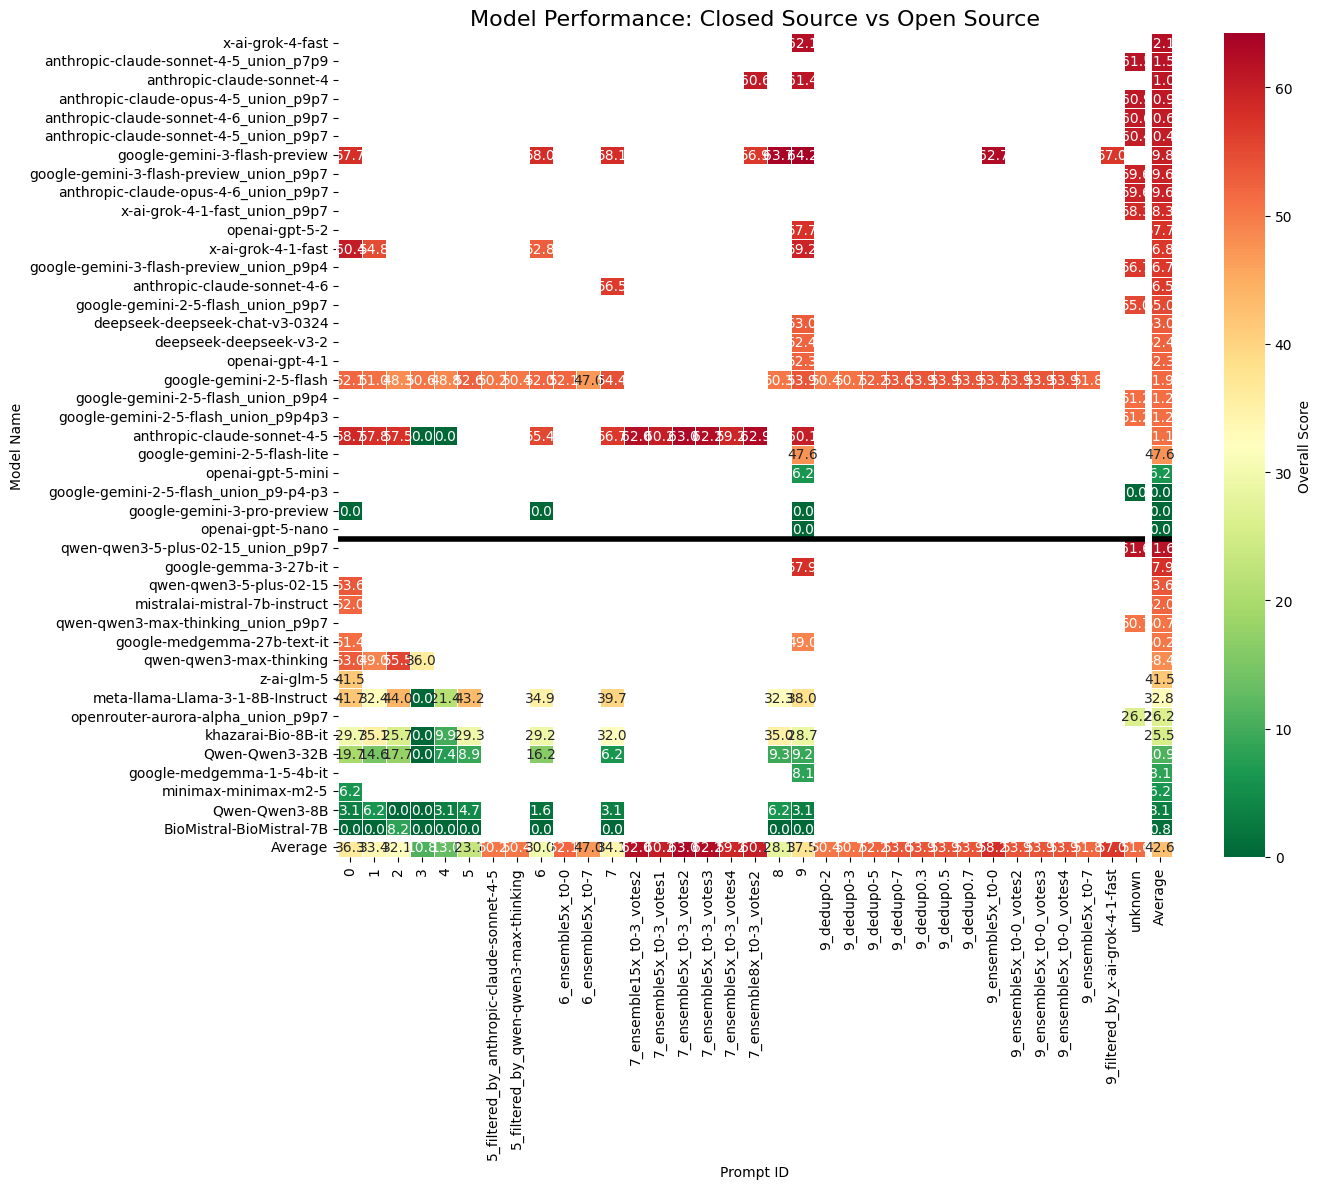

In [41]:
plt.figure(figsize=(14, 12))

ax = sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={'label': 'Overall Score'}
)

sep_idx = len(closed_sorted)

ax.axhline(y=sep_idx, color='black', linewidth=4)

ax.axvline(x=pivot_df.shape[1]-1, color='white', linewidth=5)

ax.axhline(y=pivot_df.shape[0]-1, color='white', linewidth=5)

plt.title("Model Performance: Closed Source vs Open Source", fontsize=16)
plt.ylabel("Model Name")
plt.xlabel("Prompt ID")

plt.tight_layout()
plt.show()

In [34]:
print(sorted(df["model"].unique()))

['BioMistral-BioMistral-7B', 'Qwen-Qwen3-32B', 'Qwen-Qwen3-8B', 'khazarai-Bio-8B-it', 'meta-llama-Llama-3-1-8B-Instruct']
